## *Pepper Prices Analysis*

---

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
import seaborn as sns;sns.set()
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from datetime import datetime,time
from plotly.offline import iplot,plot,init_notebook_mode,download_plotlyjs
%matplotlib inline 
init_notebook_mode(connected=True)

---

In [2]:
df=pd.read_csv('Data_Sets/actual_data.csv')
df.head()

,week_start_dt,week_end_dt,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,china,brazil_season,indonesia_season,india_season,china_season,jordan_max_price,jordan_min_price,demand,supply
0,2015-08-17,2015-08-23,1,yellow,7.249725,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.425,7.025,0.5,0.5
1,2015-08-17,2015-08-23,1,red,7.600215,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,8.125,7.825,0.5,0.5
2,2015-08-17,2015-08-23,1,green,7.074805,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.525,7.225,0.5,0.5
3,2015-08-24,2015-08-30,1,green,7.025085,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.425,7.225,0.5,0.5
4,2015-08-24,2015-08-30,1,red,7.722255,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,8.125,7.825,0.5,0.5


---

In [3]:
df.shape

(1272, 19)

* *Removing the rows with value -1*

In [4]:
df=df[df["total_volume"]!=-1]
df.shape

(1215, 19)

* *Na Values :*

In [5]:
print(f"The number of Na values is : {df.isna().sum().sum()}")
print("The number of Na values per column -if exist- is :")
df.isna().sum()

The number of Na values is : 62
The number of Na values per column -if exist- is :


week_start_dt        0
week_end_dt          0
vietnam_season       0
p_color              0
price                0
total_volume         0
brazil               0
india                0
vietnam              0
indonesia            0
china                0
brazil_season        0
indonesia_season     0
india_season         0
china_season         0
jordan_max_price    31
jordan_min_price    31
demand               0
supply               0
dtype: int64

* *Fiiling Na vlaues using interplolate with linear moethod*

In [6]:
df.interpolate(method="linear",inplace=True,limit_direction="backward")

In [7]:
print(f"The number of Na values is : {df.isna().sum().sum()}")

The number of Na values is : 0


* *dataset info :*

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1215 entries, 57 to 1271
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week_start_dt     1215 non-null   object 
 1   week_end_dt       1215 non-null   object 
 2   vietnam_season    1215 non-null   int64  
 3   p_color           1215 non-null   object 
 4   price             1215 non-null   float64
 5   total_volume      1215 non-null   float64
 6   brazil            1215 non-null   float64
 7   india             1215 non-null   float64
 8   vietnam           1215 non-null   float64
 9   indonesia         1215 non-null   float64
 10  china             1215 non-null   float64
 11  brazil_season     1215 non-null   bool   
 12  indonesia_season  1215 non-null   bool   
 13  india_season      1215 non-null   bool   
 14  china_season      1215 non-null   bool   
 15  jordan_max_price  1215 non-null   float64
 16  jordan_min_price  1215 non-null   float64
 17 

* *Number of unique values in each feature :*

In [9]:
df.nunique().to_frame().rename(columns={0:"Number of unique values"}).sort_values(by="Number of unique values",ascending=False).T

,demand,supply,price,vietnam,week_end_dt,week_start_dt,total_volume,brazil,indonesia,india,jordan_max_price,jordan_min_price,china,p_color,vietnam_season,brazil_season,indonesia_season,india_season,china_season
Number of unique values,1196,890,809,405,405,405,405,336,185,177,101,97,82,3,3,2,2,2,2


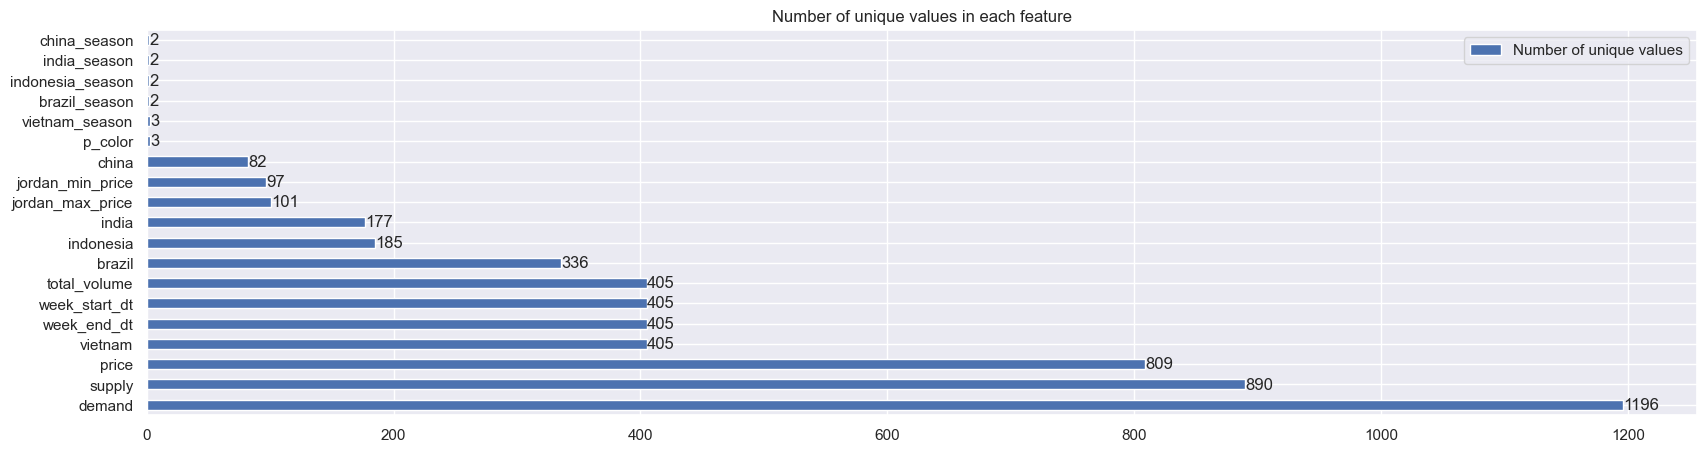

In [10]:
ax=df.nunique().to_frame().rename(columns={0:"Number of unique values"}).sort_values(by="Number of unique values",
                                                                                  ascending=False).plot(kind="barh",figsize=(20,5),title="Number of unique values in each feature");

ax.bar_label(ax.containers[0]);

* *Convert week_start_dt & week_end_dt to datetime datatype :*

In [11]:
df['week_start_dt']=pd.to_datetime(df['week_start_dt'])
df['week_end_dt']=pd.to_datetime(df['week_end_dt'])

* *Detect numerical_cols,categorical_cols,boolean_cols, and date_cols :*

In [12]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
boolean_cols=df.select_dtypes(include='bool').columns.tolist()
date_cols=df.select_dtypes(include='datetime').columns.tolist()

In [13]:
print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

numerical_cols : 
['vietnam_season', 'price', 'total_volume', 'brazil', 'india', 'vietnam', 'indonesia', 'china', 'jordan_max_price', 'jordan_min_price', 'demand', 'supply']
--------------------------------------------------
categorical_cols : 
['p_color']
--------------------------------------------------
boolean_cols : 
['brazil_season', 'indonesia_season', 'india_season', 'china_season']
--------------------------------------------------
date_cols : 
['week_start_dt', 'week_end_dt']


* *EDA*

In [14]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
vietnam_season,1215.0,1.918519e+00,0.770616,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00
price,1215.0,8.008801e+00,1.367471,6.299625,7.000047e+00,7.600120e+00,8.600505e+00,1.408459e+01
total_volume,1215.0,2.244701e+06,482013.003283,325471.000000,1.938246e+06,2.254902e+06,2.541123e+06,3.555979e+06
brazil,1215.0,2.453030e+05,238532.956065,0.000000,1.060860e+04,1.754931e+05,4.435506e+05,8.776478e+05
india,1215.0,2.874410e+04,55904.812350,0.000000,0.000000e+00,0.000000e+00,3.102260e+04,3.489974e+05
vietnam,1215.0,1.806530e+06,573830.707115,220121.500000,1.402234e+06,1.785219e+06,2.204095e+06,3.549175e+06
indonesia,1215.0,1.549481e+05,243242.278078,0.000000,0.000000e+00,2.150300e+03,2.784692e+05,1.061051e+06
china,1215.0,8.487645e+03,21366.041220,0.000000,0.000000e+00,0.000000e+00,7.257400e+03,2.109202e+05
jordan_max_price,1215.0,8.509403e+00,1.494271,6.225000,7.425000e+00,8.025000e+00,9.225000e+00,1.422500e+01
jordan_min_price,1215.0,7.926667e+00,1.367845,6.025000,6.925000e+00,7.525000e+00,8.525000e+00,1.372500e+01


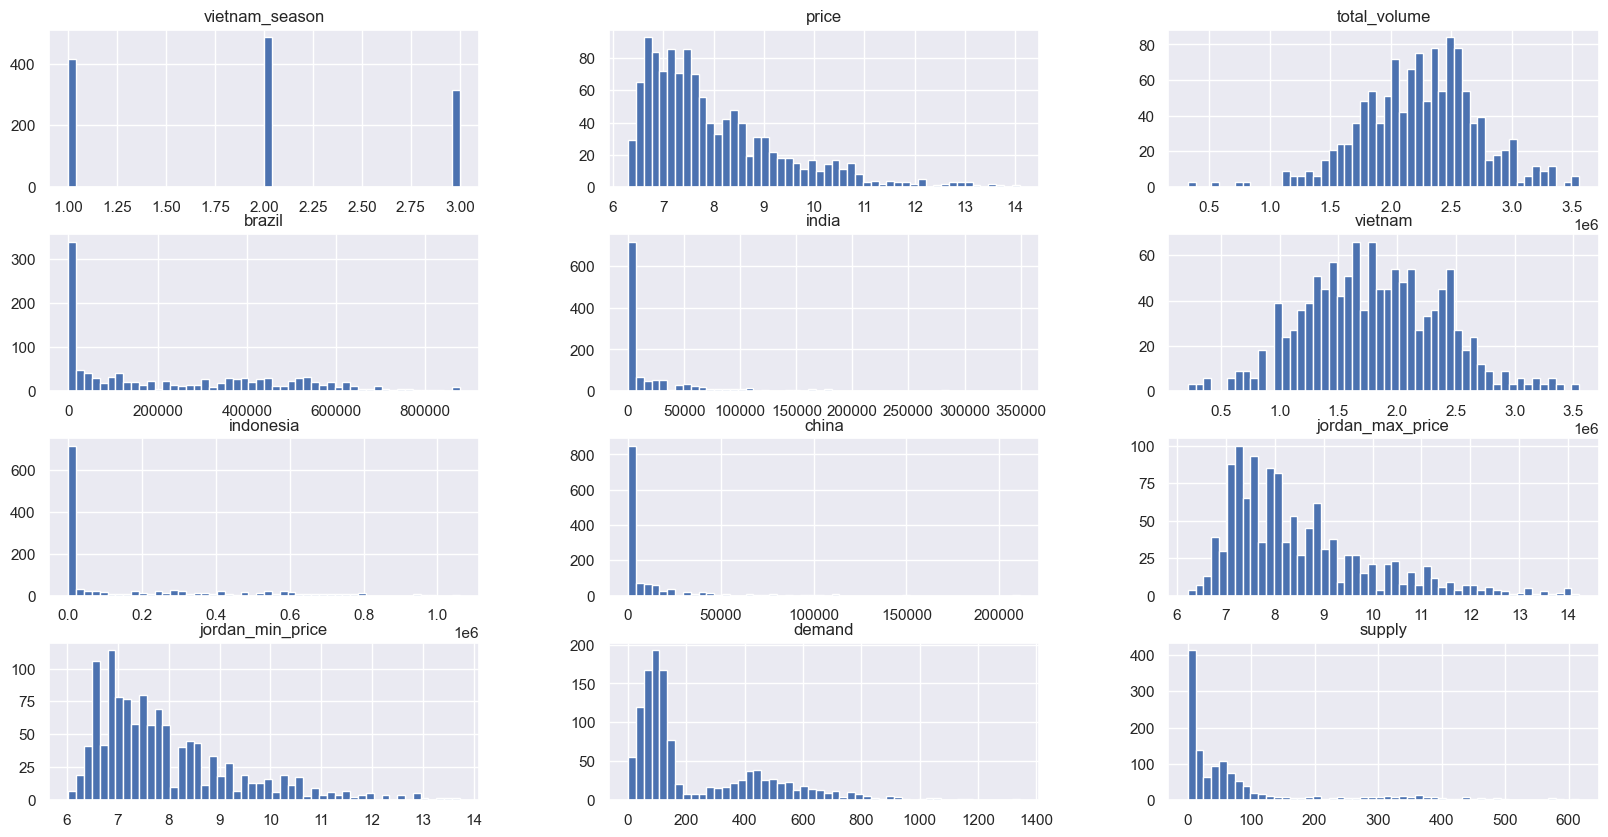

In [15]:
%matplotlib inline 
import matplotlib.pyplot as plt
df[numerical_cols].hist(bins=50, figsize=(20,10))
plt.show()

* *Define data distribution for numerical features :*

In [16]:
import scipy.stats as stats
distributions = ['norm', 'expon', 'gamma', 'lognorm', 'beta', 'uniform','logistic','triang','weibull_min','weibull_max','pareto']
def best_fit(df,distributions):
    best_fit = {}
    errors = []
    for i in numerical_cols:
        data = pd.to_numeric(df[i])
        for dist_name in distributions:
            dist = getattr(stats, dist_name)
            params = dist.fit(data)
            ks_stat, p_value = stats.kstest(data, dist_name, args=params)
            best_fit[dist_name] = p_value 
            #print(f"{dist_name}: p-value = {p_value:.4f}")

        best_distribution = max(best_fit, key=best_fit.get)
        print(f"Best fitting distribution for the feature {i}:==> {best_distribution} with p-value = {best_fit[best_distribution]:.4f}")  

best_fit(df=df,distributions=distributions)

Best fitting distribution for the feature vietnam_season:==> logistic with p-value = 0.0000
Best fitting distribution for the feature price:==> lognorm with p-value = 0.1280
Best fitting distribution for the feature total_volume:==> lognorm with p-value = 0.1775
Best fitting distribution for the feature brazil:==> norm with p-value = 0.0000
Best fitting distribution for the feature india:==> norm with p-value = 0.0000
Best fitting distribution for the feature vietnam:==> beta with p-value = 0.5312
Best fitting distribution for the feature indonesia:==> logistic with p-value = 0.0000
Best fitting distribution for the feature china:==> norm with p-value = 0.0000
Best fitting distribution for the feature jordan_max_price:==> lognorm with p-value = 0.0143
Best fitting distribution for the feature jordan_min_price:==> lognorm with p-value = 0.0020
Best fitting distribution for the feature demand:==> lognorm with p-value = 0.0000
Best fitting distribution for the feature supply:==> norm with

In [17]:
corr_matrix = df[numerical_cols].corr(method='kendall')
corr_matrix

,vietnam_season,price,total_volume,brazil,india,vietnam,indonesia,china,jordan_max_price,jordan_min_price,demand,supply
vietnam_season,1.000000,-0.110692,0.076351,0.036626,-0.088580,0.263041,-0.416143,-0.139930,-0.133001,-0.111500,0.033630,0.021674
price,-0.110692,1.000000,-0.074086,0.191875,-0.018944,-0.238479,0.264413,0.048962,0.876552,0.882043,0.280564,0.043531
total_volume,0.076351,-0.074086,1.000000,0.127569,-0.258146,0.522234,0.042517,0.262401,-0.081399,-0.063816,0.075580,0.362152
brazil,0.036626,0.191875,0.127569,1.000000,-0.469476,-0.259652,0.407216,0.064724,0.168929,0.175993,0.020222,0.027132
india,-0.088580,-0.018944,-0.258146,-0.469476,1.000000,0.040480,-0.325707,-0.245752,-0.000441,-0.010598,-0.068415,-0.261851
vietnam,0.263041,-0.238479,0.522234,-0.259652,0.040480,1.000000,-0.411314,0.065032,-0.243133,-0.222723,0.069731,0.275957
indonesia,-0.416143,0.264413,0.042517,0.407216,-0.325707,-0.411314,1.000000,0.243741,0.263802,0.258077,-0.001360,0.065183
china,-0.139930,0.048962,0.262401,0.064724,-0.245752,0.065032,0.243741,1.000000,0.050357,0.053948,0.006198,0.398490
jordan_max_price,-0.133001,0.876552,-0.081399,0.168929,-0.000441,-0.243133,0.263802,0.050357,1.000000,0.909464,0.269733,0.046322
jordan_min_price,-0.111500,0.882043,-0.063816,0.175993,-0.010598,-0.222723,0.258077,0.053948,0.909464,1.000000,0.289573,0.055633


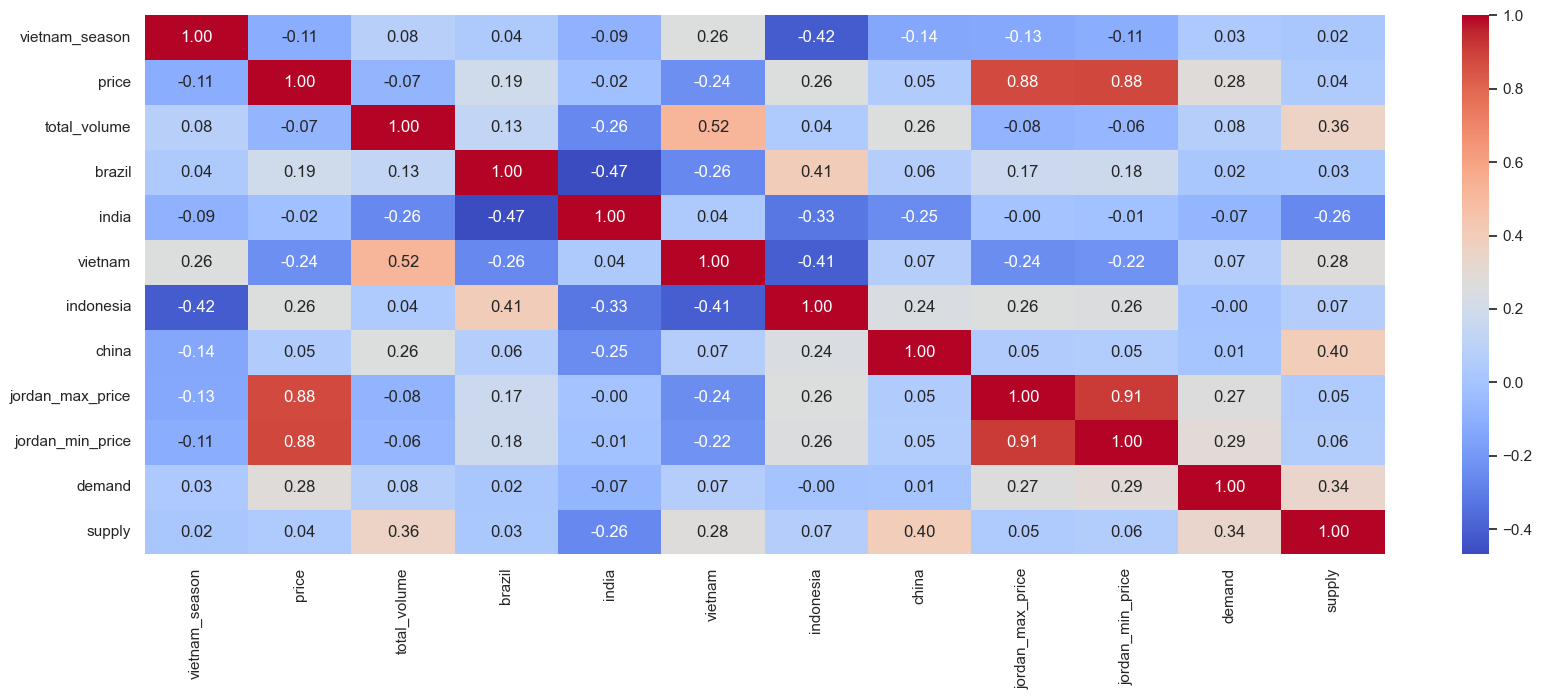

In [23]:
plt.figure(figsize=(20,7))
ax=sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f");

In [24]:
corr_matrix["price"].sort_values(ascending=False)

price               1.000000
jordan_min_price    0.882043
jordan_max_price    0.876552
demand              0.280564
indonesia           0.264413
brazil              0.191875
china               0.048962
supply              0.043531
india              -0.018944
total_volume       -0.074086
vietnam_season     -0.110692
vietnam            -0.238479
Name: price, dtype: float64

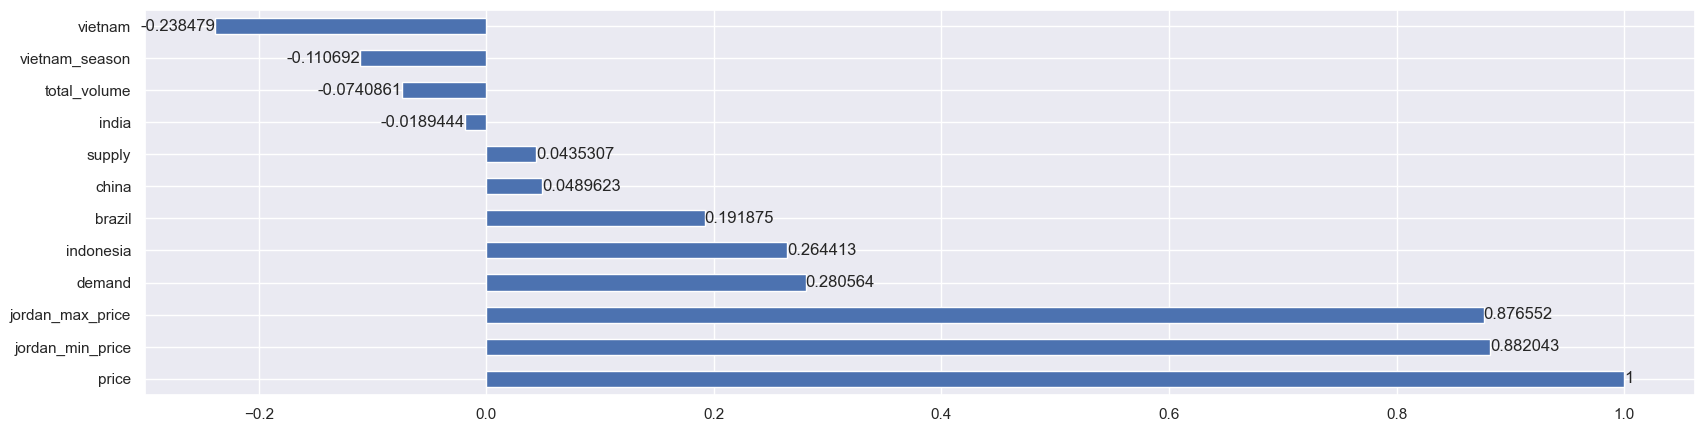

In [25]:
plt.figure(figsize=(20,5))
ax=corr_matrix["price"].sort_values(ascending=False).plot(kind='barh')
ax.bar_label(ax.containers[0]);

* *Categorical features :*

In [26]:
df[categorical_cols].describe().T

,count,unique,top,freq
p_color,1215,3,green,405


In [27]:
df[categorical_cols].value_counts()

p_color
green      405
red        405
yellow     405
Name: count, dtype: int64

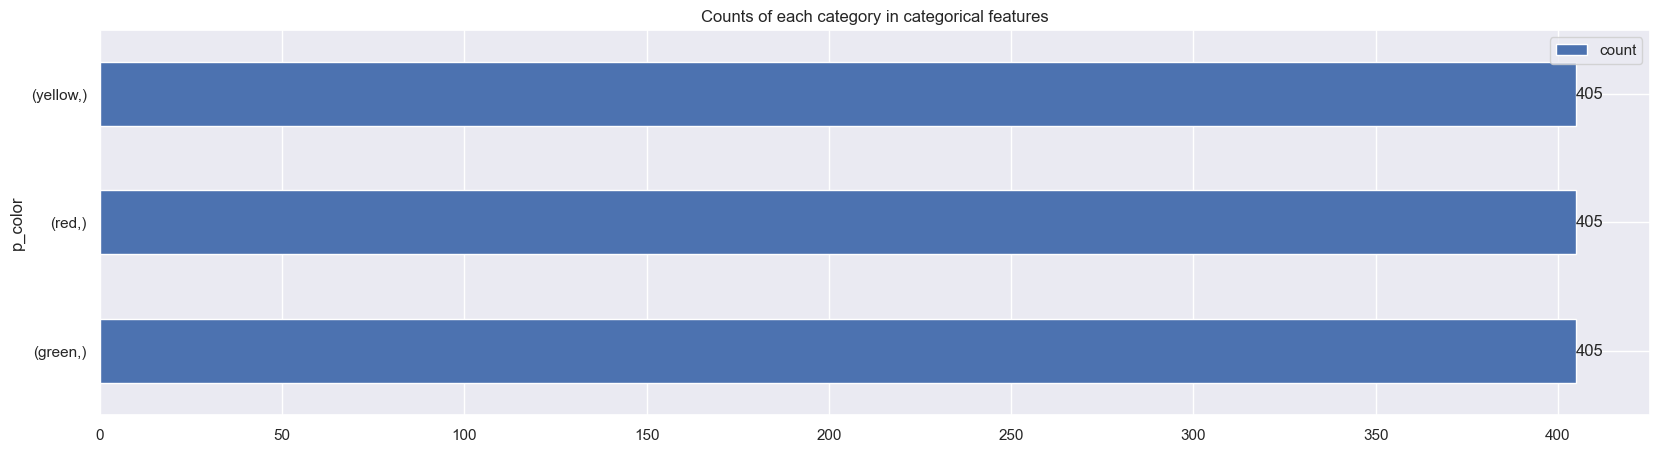

In [28]:
ax=df[categorical_cols].value_counts().to_frame().rename(columns={0:"Counts"}).plot(kind="barh",figsize=(20,5),title="Counts of each category in categorical features")
ax.bar_label(ax.containers[0]);

* *boolean features :*

In [29]:
df[boolean_cols].describe()

,brazil_season,indonesia_season,india_season,china_season
count,1215,1215,1215,1215
unique,2,2,2,2
top,False,False,False,False
freq,690,903,912,801


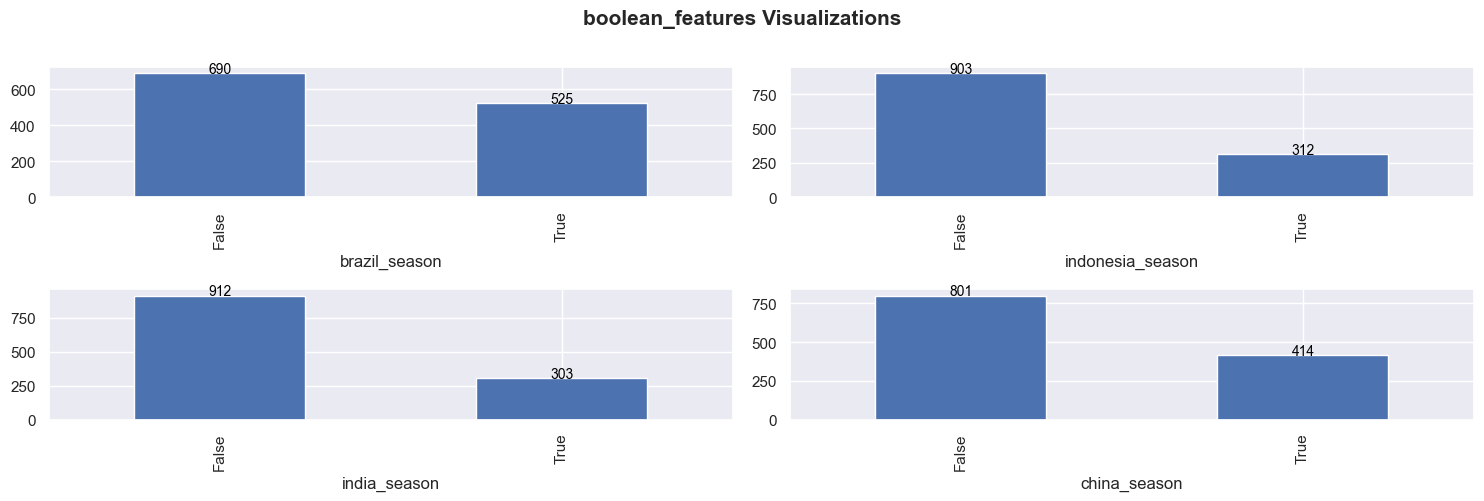

In [30]:
def plot_boolean_features(boolean_features):
    nrows = 2
    ncols = 2
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5))
    fig.suptitle(f"boolean_features Visualizations",fontsize=15,fontweight="bold",y=1.)

    axes = axes.flatten()
    
    for i, column in enumerate(boolean_features.columns):
        if i >= nrows * ncols:
            break 
        ax = axes[i]
        counts = boolean_features[column].value_counts()
        counts.plot(kind='bar', ax=ax)
        
        for bar in ax.patches:
            ax.annotate(
                str(bar.get_height()),
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 3),
                textcoords='offset points'
            )
        
    plt.tight_layout()
    plt.show()

plot_boolean_features(df[boolean_cols])  

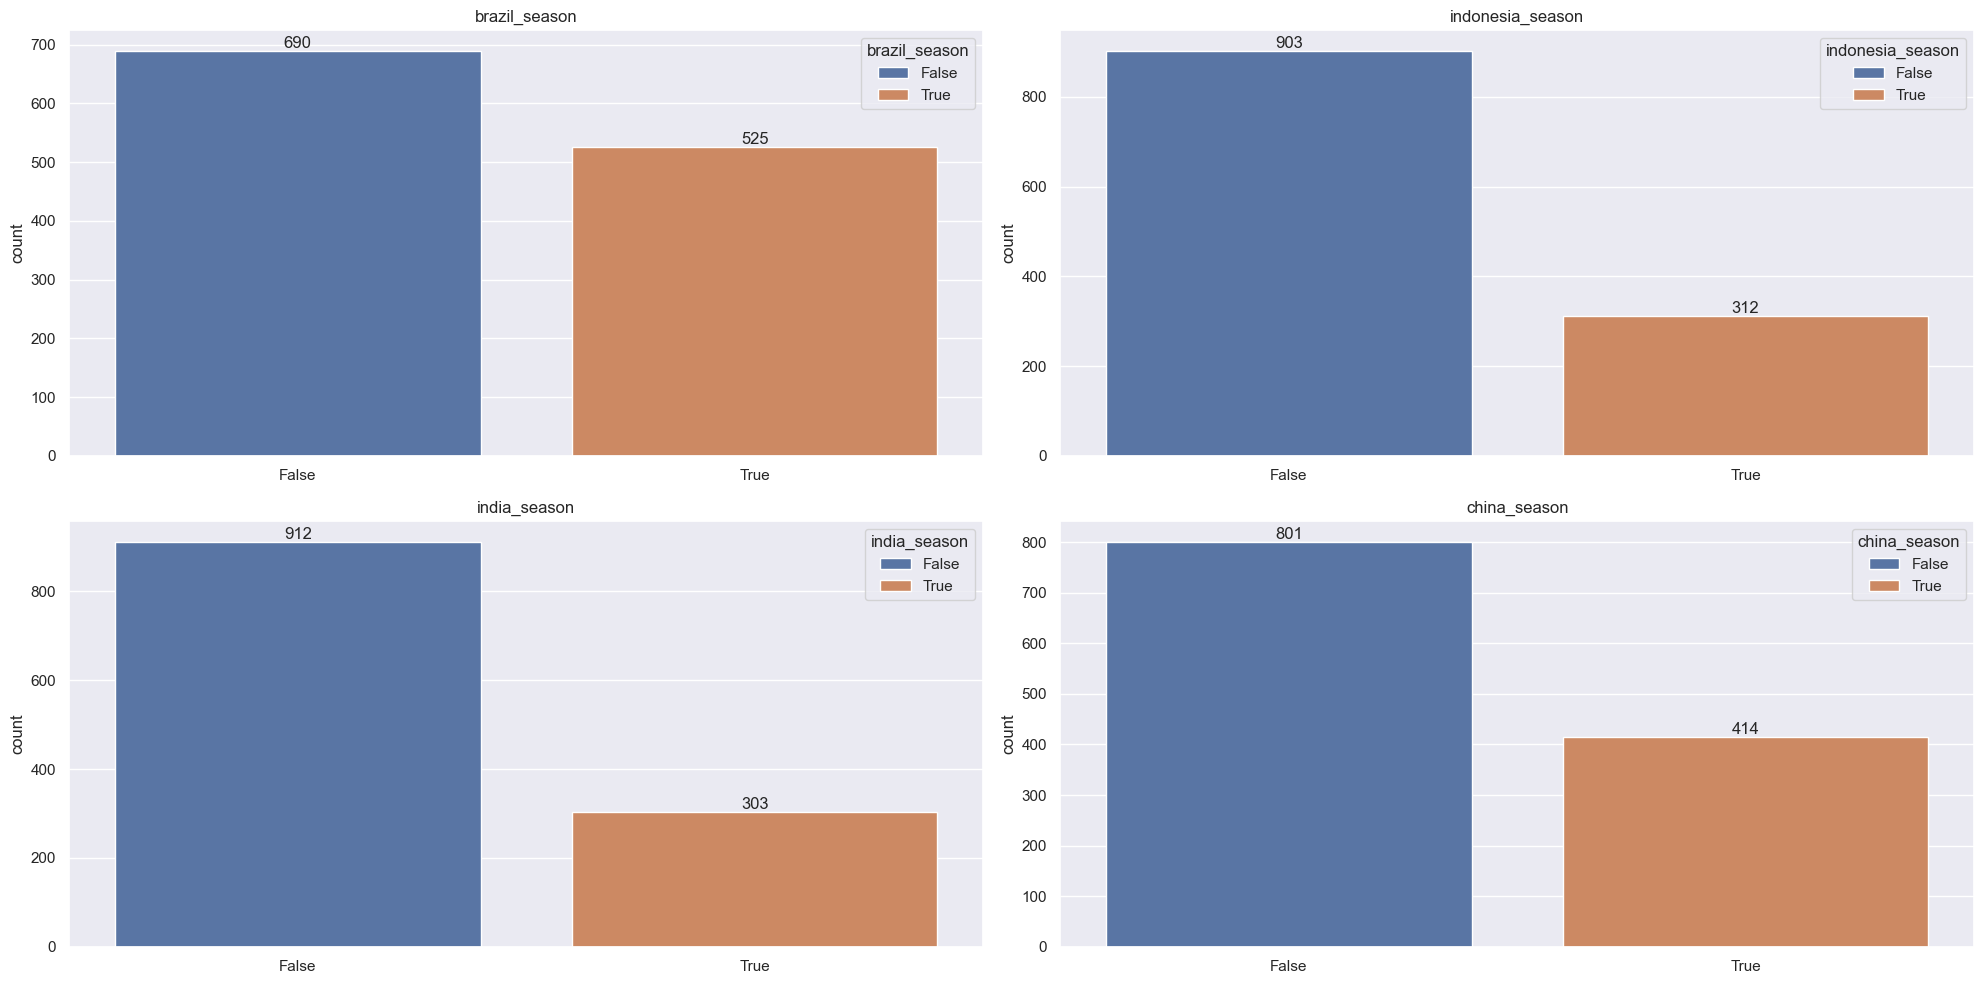

In [305]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df, x="brazil_season", ax=ax1,hue='brazil_season')
ax1.set_title("brazil_season")
ax1.set_xlabel("")
for container in ax1.containers:
    ax1.bar_label(container)

ax2 = fig.add_subplot(gs[0, 1])
Area_order=['A','B','C','D','E','F']
sns.countplot(data=df, x="indonesia_season", ax=ax2,hue='indonesia_season')
ax2.set_title("indonesia_season")
ax2.set_xlabel("")
for container in ax2.containers:
    ax2.bar_label(container)

ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x="india_season", ax=ax3,hue='india_season')
ax3.set_title("india_season")
ax3.set_xlabel("")
for container in ax3.containers:
    ax3.bar_label(container) 


ax4 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x="china_season", ax=ax4,hue='china_season')
ax4.set_title("china_season")
ax4.set_xlabel("")
for container in ax4.containers:
    ax4.bar_label(container)  


plt.tight_layout()
plt.show()

* *More Data Engeneering :*

*Create new features from existing ones : year,month_name,month,year_int,day_name,Weekday_Number,and DayOfMonth*

In [31]:
df_copy=df.copy()
df_copy["month"]=df_copy["week_start_dt"].dt.month
df_copy["year"]=df_copy["week_start_dt"].dt.year
df_copy["day_name"]=df_copy["week_start_dt"].dt.day_name()
df_copy['Weekday_Number'] = df_copy["week_start_dt"].dt.dayofweek
df_copy['DayOfMonth'] = df_copy['week_start_dt'].dt.day

In [32]:
df_copy

,week_start_dt,week_end_dt,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,...,china_season,jordan_max_price,jordan_min_price,demand,supply,month,year,day_name,Weekday_Number,DayOfMonth
57,2015-12-28,2016-01-03,2,green,6.599075,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,6.625,6.325,0.50,0.500000,12,2015,Monday,0,28
58,2015-12-28,2016-01-03,2,red,7.175335,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,7.525,7.125,0.51,0.500000,12,2015,Monday,0,28
59,2015-12-28,2016-01-03,2,yellow,7.300575,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,7.425,7.025,16.55,0.500000,12,2015,Monday,0,28
60,2016-01-04,2016-01-10,2,yellow,7.379675,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,7.525,7.025,271.16,0.500000,1,2016,Monday,0,4
61,2016-01-04,2016-01-10,2,red,7.175335,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,7.625,7.125,42.33,0.500000,1,2016,Monday,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2023-09-18,2023-09-24,1,red,7.334644,2761128.0,8695.6,29937.0,2530027.4,180220.8,...,True,7.725,7.225,88.64,51.002726,9,2023,Monday,0,18
1268,2023-09-18,2023-09-24,1,yellow,9.008137,2761128.0,8695.6,29937.0,2530027.4,180220.8,...,True,9.825,9.225,305.26,312.634513,9,2023,Monday,0,18
1269,2023-09-25,2023-10-01,1,red,7.259712,2665343.9,167.8,45376.1,2521054.0,78334.2,...,False,7.825,7.425,97.34,39.690619,9,2023,Monday,0,25
1270,2023-09-25,2023-10-01,1,green,6.910027,2665343.9,167.8,45376.1,2521054.0,78334.2,...,False,7.125,6.825,102.85,60.310000,9,2023,Monday,0,25


In [33]:
cols=['year','month','day_name','Weekday_Number','DayOfMonth']

df_copy[cols].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,1215.0,NaN,NaN,NaN,2019.37284,2.245644,2015.0,2017.0,2019.0,2021.0,2023.0
month,1215.0,NaN,NaN,NaN,6.375309,3.4098,1.0,3.0,6.0,9.0,12.0
day_name,1215,1,Monday,1215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekday_Number,1215.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DayOfMonth,1215.0,NaN,NaN,NaN,15.787654,8.799769,1.0,8.0,16.0,23.0,31.0


*will drop the day name as it has only one unique value for all*

In [35]:
df_copy=df_copy.drop(["day_name","Weekday_Number"],axis=1)

In [36]:
df_copy2=df_copy.copy()
df_copy2[['brazil_season', 'indonesia_season', 'india_season', 'china_season']]=df_copy2[['brazil_season', 'indonesia_season', 'india_season', 'china_season']].astype("int")

* *Seasons Overlaping :*

In [41]:
df_seasons=df_copy2[['month','vietnam_season','brazil_season','india_season','china_season','indonesia_season']]
df_seasons.groupby(['month','vietnam_season','india_season','china_season','indonesia_season','brazil_season']).count()

Empty DataFrame
Columns: []
Index: [(1, 2, 0, 0, 0, 0), (2, 2, 0, 0, 0, 0), (3, 3, 0, 0, 0, 0), (3, 3, 0, 0, 0, 1), (4, 3, 0, 0, 0, 1), (5, 3, 0, 0, 0, 1), (5, 3, 0, 1, 1, 1), (6, 1, 0, 1, 1, 1), (7, 1, 0, 1, 1, 1), (7, 1, 1, 1, 1, 1), (8, 1, 1, 1, 0, 0), (8, 1, 1, 1, 1, 1), (9, 1, 1, 0, 0, 0), (9, 1, 1, 1, 0, 0), (10, 2, 0, 0, 0, 0), (10, 2, 1, 0, 0, 0), (11, 2, 0, 0, 0, 0), (12, 2, 0, 0, 0, 0)]

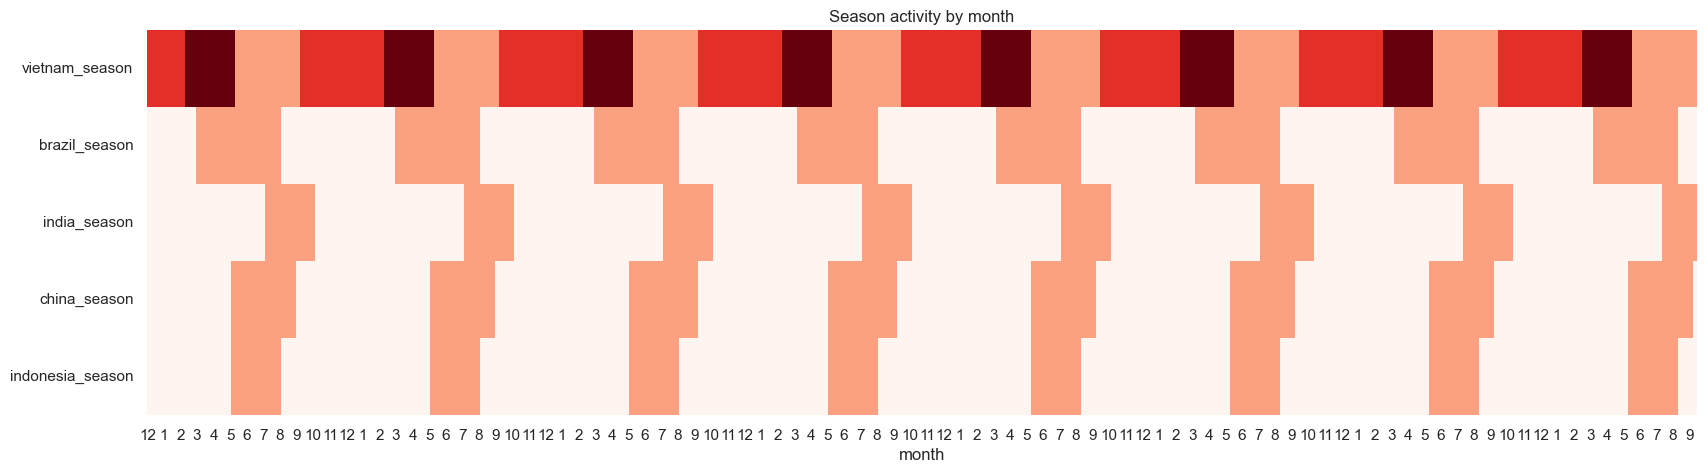

In [39]:
import seaborn as sns
plt.subplots(figsize=(20,5))
sns.heatmap(df_seasons.set_index('month').T, cmap="Reds", cbar=False)
plt.title("Season activity by month")
plt.show()


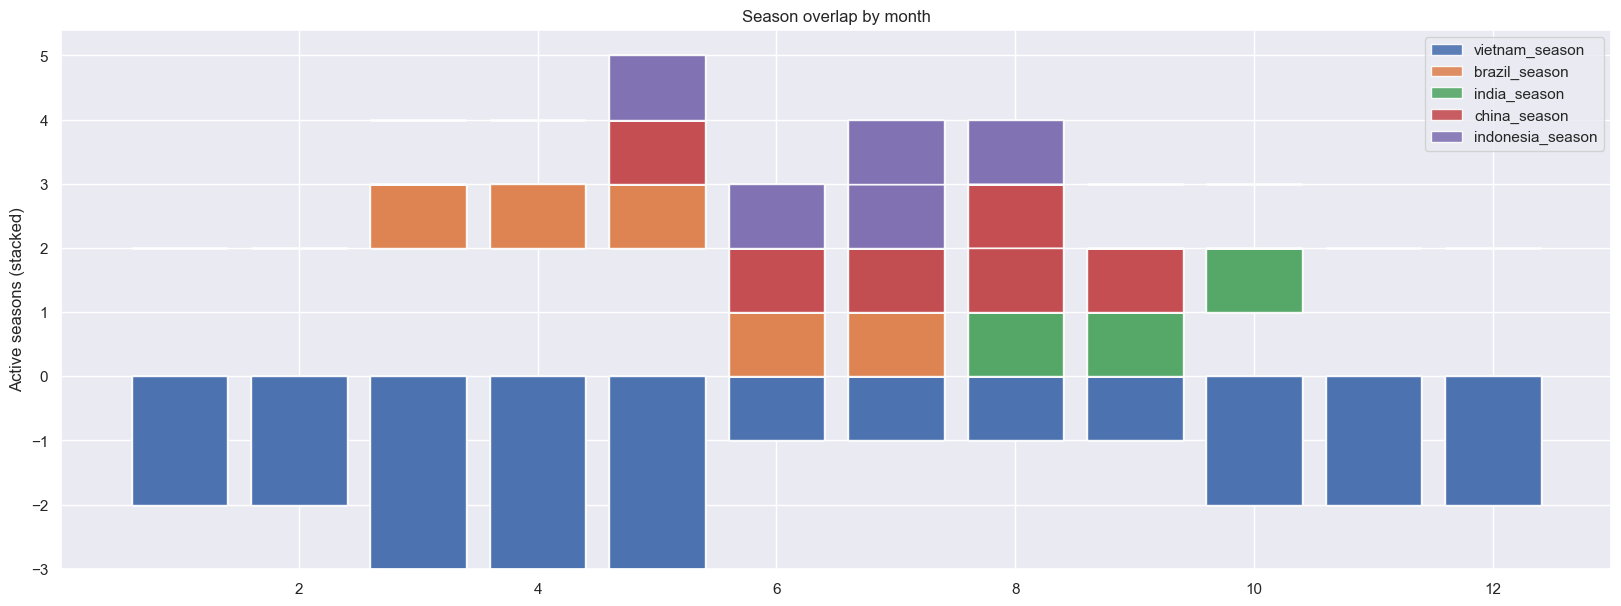

In [40]:
fig, ax = plt.subplots(figsize=(20, 7))
for i, season in enumerate(['vietnam_season', 'brazil_season', 'india_season','china_season','indonesia_season']):
    ax.bar(df_seasons['month'], df_seasons[season], bottom=df_seasons.iloc[:, 1:i+1].sum(axis=1)-df_seasons[season],
          label=season, alpha=0.9)

ax.legend()
ax.set_ylabel("Active seasons (stacked)")
#ax.set_yticklabels("")

plt.title("Season overlap by month")
plt.show()

* *Propability*

*As our target is the ptice feature we will only be focussing on*

In [112]:
def price_empirical_prob(threshold):
    #threshold=float(input("Enter price threshold(price range 6-14)"))
    prob_price_above_threshold = np.mean(df_copy["price"] > threshold)
    print(f"Probability(price > {threshold}) = {prob_price_above_threshold:.2f}==> means :\n{prob_price_above_threshold:.2f} of of observed prices are above {threshold}")
    
price_empirical_prob(threshold=10)

Probability(price > 10) = 0.10==> means :
0.10 of of observed prices are above 10


In [54]:
min_price=df_copy["price"].min()
max_price=df_copy["price"].max()
print(f"min price is : {min_price:.2f},\nmax price is : {max_price:.2f}")

min price is : 6.30,
max price is : 14.08


In [120]:
from scipy.stats import lognorm, gamma

In [122]:
def price_Prob_distribution(threshold):
    shape, loc, scale = lognorm.fit(df["price"])
    prob_gt = 1 - lognorm.cdf(threshold, shape, loc, scale)
    print(f"P(price = {threshold}) = {prob_gt:.3f}")

price_Prob_distribution(threshold=8)

P(price = 8) = 0.370


In [125]:
df_copy["brazil"].describe()    

count      1215.000000
mean     245303.031852
std      238532.956065
min           0.000000
25%       10608.600000
50%      175493.100000
75%      443550.600000
max      877647.800000
Name: brazil, dtype: float64

In [135]:
def price_conditional_empirical_prob(threshold,condition):
    prob_conditional = np.mean(df_copy["price"][condition])

    print(f"P(price > {threshold} | {condition}) = {prob_conditional:.2f},==> means :\n{prob_conditional:.2f} of of observed prices are above {threshold}")
    
price_conditional_empirical_prob(threshold=10,condition=df_copy["p_color"] =="Red")

P(price > 10 | 57      False
58      False
59      False
60      False
61      False
        ...  
1267    False
1268    False
1269    False
1270    False
1271    False
Name: p_color, Length: 1215, dtype: bool) = nan,==> means :
nan of of observed prices are above 10


In [97]:
# Define conditions
condition = df_copy["vietnam_season"] == 2
threshold=9

# Conditional probability
prob_conditional = np.mean(df_copy["price"][condition])

print(f"P(price > 60 | vietnam_season == 1) = {prob_conditional:.2f},==> means :\n{prob_conditional:.2f} of of observed prices are above {threshold}")


P(price > 60 | vietnam_season == 1) = 7.46,==> means :
7.46 of of observed prices are above 9


In [98]:
subset = df_copy[condition]["price"]

shape, loc, scale = lognorm.fit(subset)
prob_gt_50 = 1 - lognorm.cdf(threshold, shape, loc, scale)
print(f"shape {shape:.2f},\nloc {loc:.2f},\nscale {scale:.2f}")
print(f"P(price > {threshold}) = {prob_gt_50:.3f}")

shape 0.77,
loc 6.22,
scale 0.93
P(price > 9) = 0.078


* *Hypothesis testing*

In [374]:
from scipy.stats import shapiro
import scipy.stats as stats   
def normaly_distibuted_check(data,column):
    from scipy.stats import shapiro
    stat, p = shapiro(data[column])
    print(f"W = {stat:.3f}, p = {p:.3f}")
    if p < 0.05:
        print("Reject H₀ → distribution is not normal")
    else:
        print("Fail to reject H₀ → distribution is compatible with normality")
  
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))   
    sns.boxplot(data=data, x=column, ax=axes[0])
    axes[0].set_title(f'{column} Boxplot')  
    sns.histplot(data=data, x=column, ax=axes[1])
    axes[1].set_title(f'{column} histogram') 
    stats.probplot(data[column], dist="norm", plot=plt)
    axes[2].set_title(f'{column} qq-plot')   

W = 0.877, p = 0.000
Reject H₀ → distribution is not normal


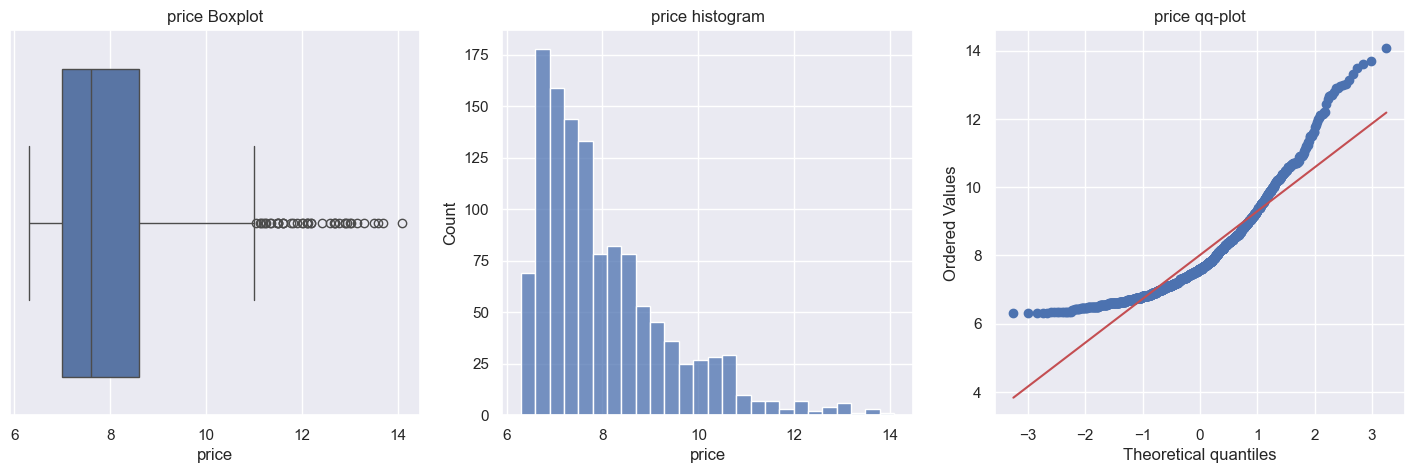

In [375]:
normaly_distibuted_check(data=df_copy,column="price")

---

In [376]:
from scipy.stats import spearmanr,mannwhitneyu
def mannwhitneyu_func(Dataset:pd.DataFrame,Numericaltarget:str,BinaryFeature:str):
    group1 = Dataset[Numericaltarget][Dataset[BinaryFeature] == 0]
    group2 = Dataset[Numericaltarget][Dataset[BinaryFeature]  == 1]
    u_stat, p_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    print(f"W = {u_stat:.3f}, p = {p_mw:.3f}")
    if p_mw < 0.05:
        print(f"As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between {Numericaltarget} & {BinaryFeature}")
    else:
        print(f"As The P-value is more than .05 : Fail to reject H₀ → No significant distribution difference between {Numericaltarget} & {BinaryFeature}")

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    sns.boxplot(x=BinaryFeature, y=Numericaltarget, data=Dataset, palette="Set2",ax=axes[0])
    sns.stripplot(x=BinaryFeature, y=Numericaltarget, data=Dataset, color="black", alpha=0.6,ax=axes[1]);
    sns.histplot(x=Numericaltarget,hue=BinaryFeature,ax=axes[2],data=Dataset,alpha=0.6)


W = 115126.000, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & brazil_season


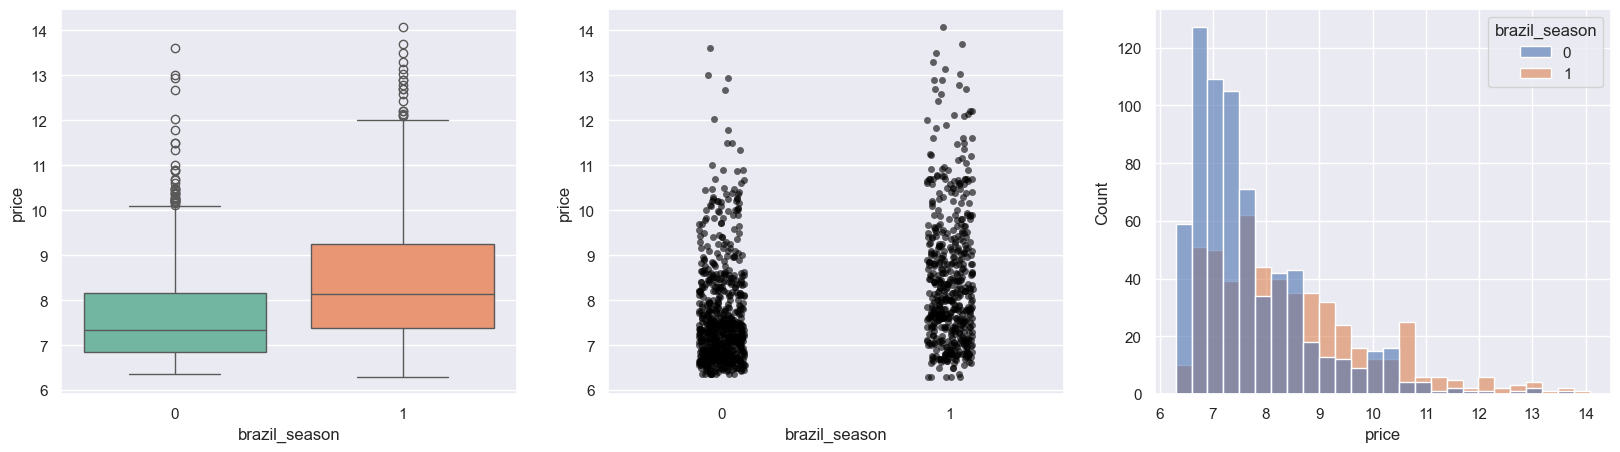

In [377]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="brazil_season")

W = 89565.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & indonesia_season


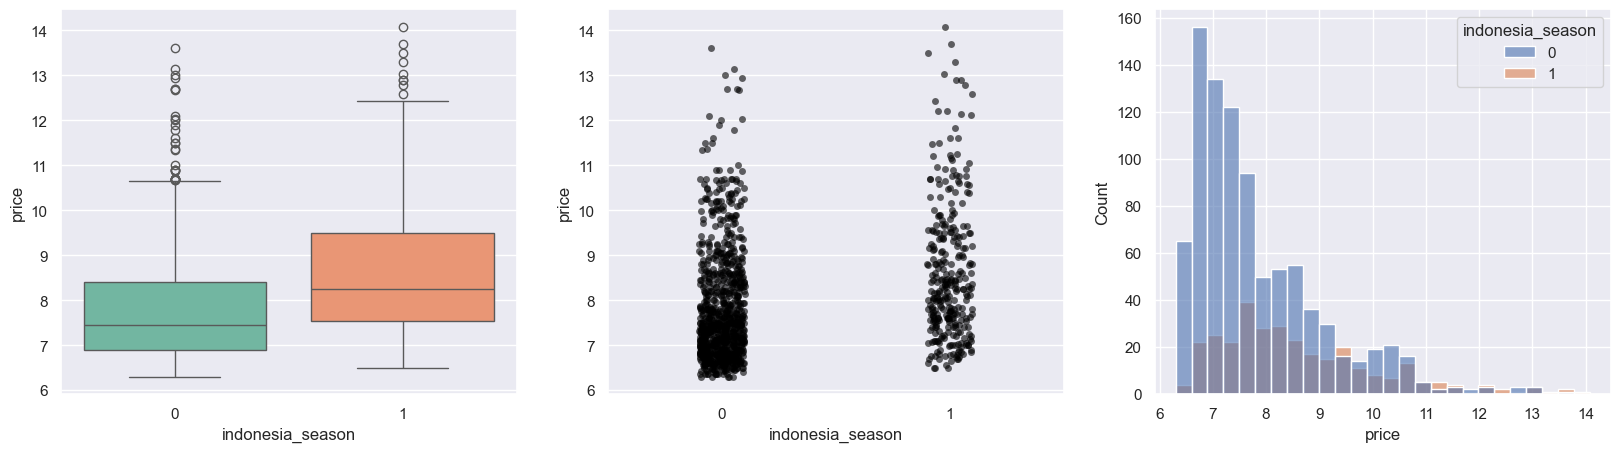

In [378]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="indonesia_season")

W = 116426.000, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & india_season


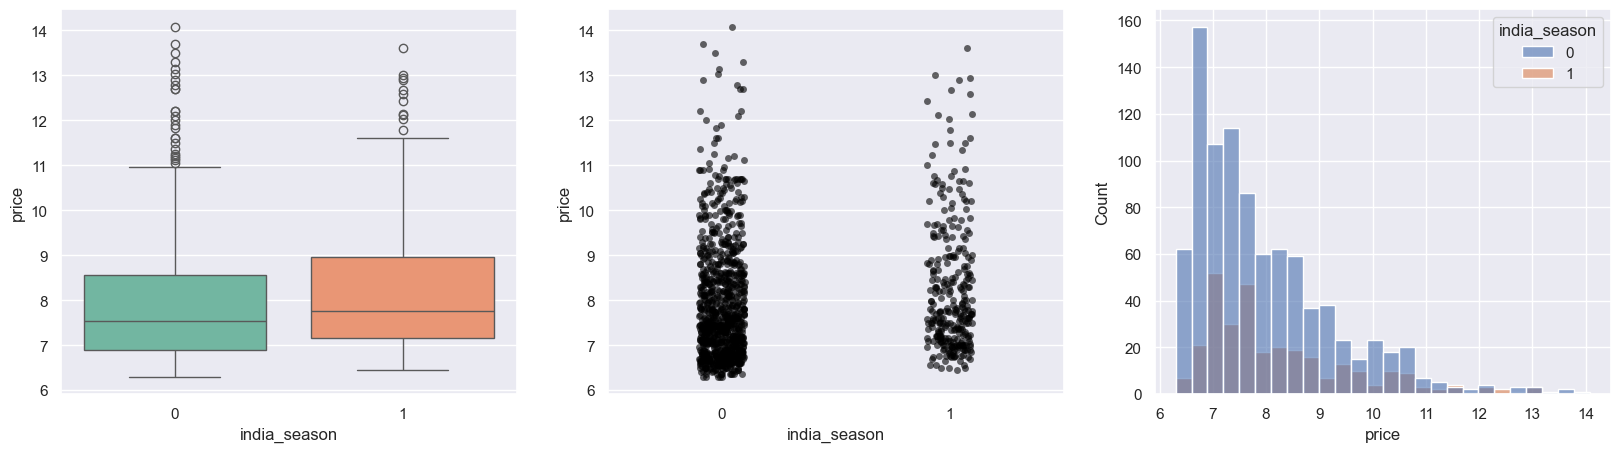

In [379]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="india_season")

W = 105169.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & china_season


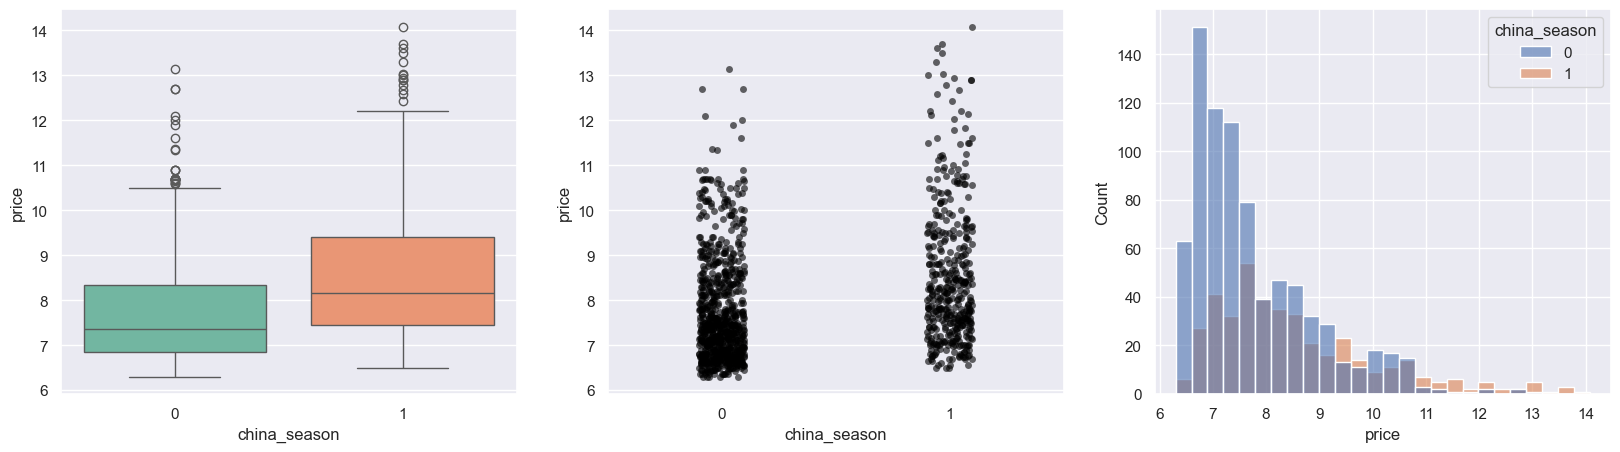

In [380]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="china_season")

In [381]:
def spearmanr_func(Dataset:pd.DataFrame,Numericaltarget:str,OrdinalFeature:str):
    spearman_corr, p_spear = spearmanr(Dataset[Numericaltarget],Dataset[OrdinalFeature])
    prob_df = Dataset.groupby(OrdinalFeature)[Numericaltarget].mean().reset_index()
    prob_df.rename(columns={Numericaltarget: 'prob_target_1'}, inplace=True)  

    print(f"W = {spearman_corr:.3f}, p = {p_spear:.3f}")
    if p_spear < 0.05:
        print(f"As The P-value is less than .05 : Reject H₀ → There is significant monotonic relationship between {Numericaltarget} & {OrdinalFeature}")
    else:
        print(f"As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between {Numericaltarget} & {OrdinalFeature}")

    plt.figure(figsize=(20,5))
    ax=sns.heatmap(prob_df.set_index(OrdinalFeature).T, annot=True, cmap="YlGnBu", cbar=True)
    ax.set_title("Probability of Binary Target=1 by Ordinal Feature")
    ax.set_xlabel("Ordinal Feature")
    ax.set_ylabel("Probability")
    plt.tight_layout()
    plt.show()  

W = -0.143, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant monotonic relationship between price & vietnam_season


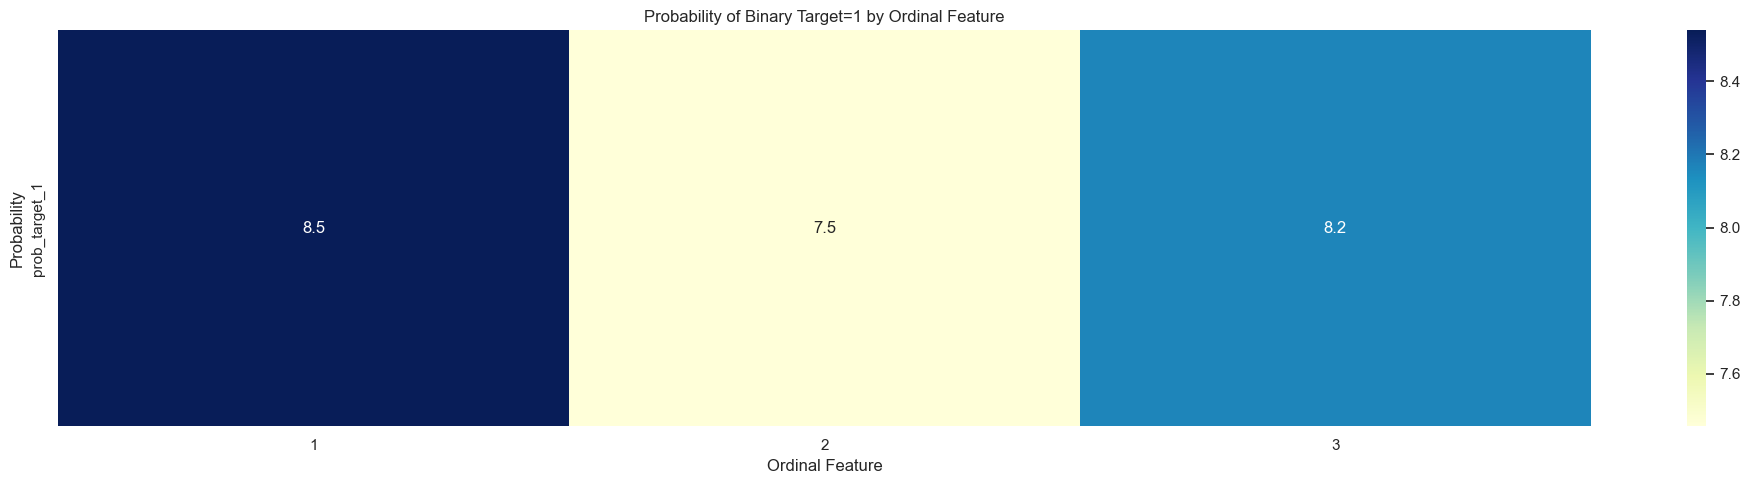

In [382]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="vietnam_season")

W = -0.009, p = 0.762
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & DayOfMonth


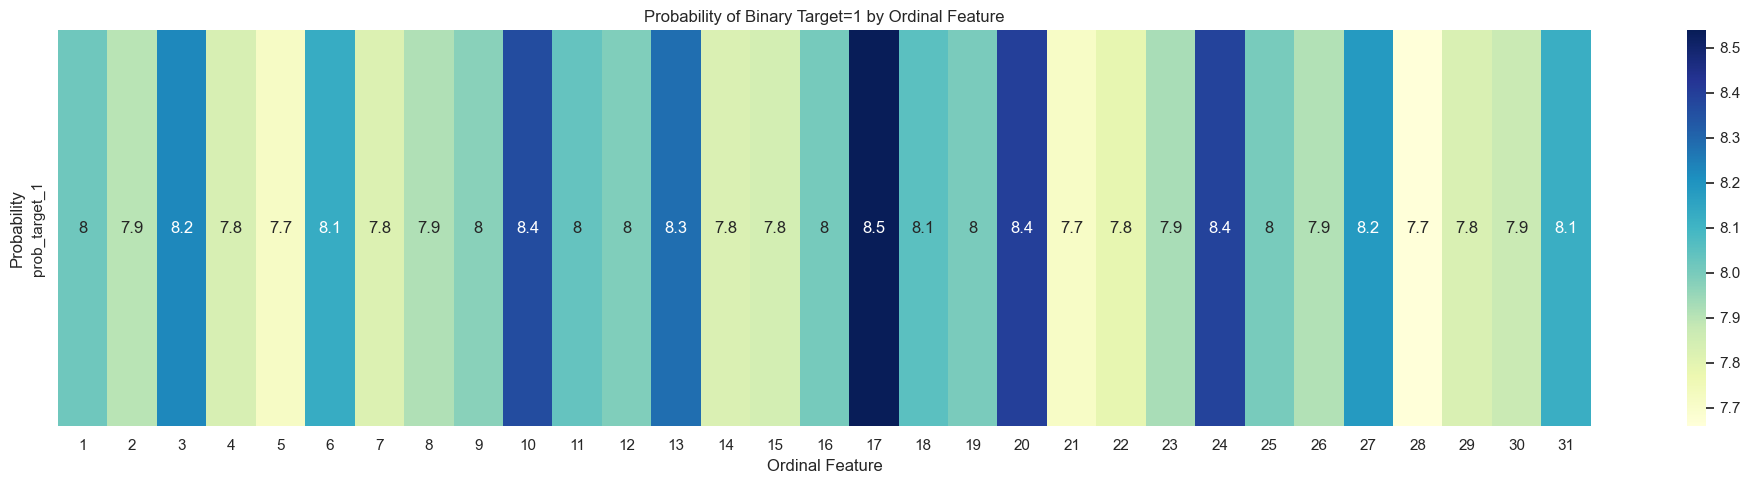

In [383]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="DayOfMonth");

W = -0.030, p = 0.296
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & month


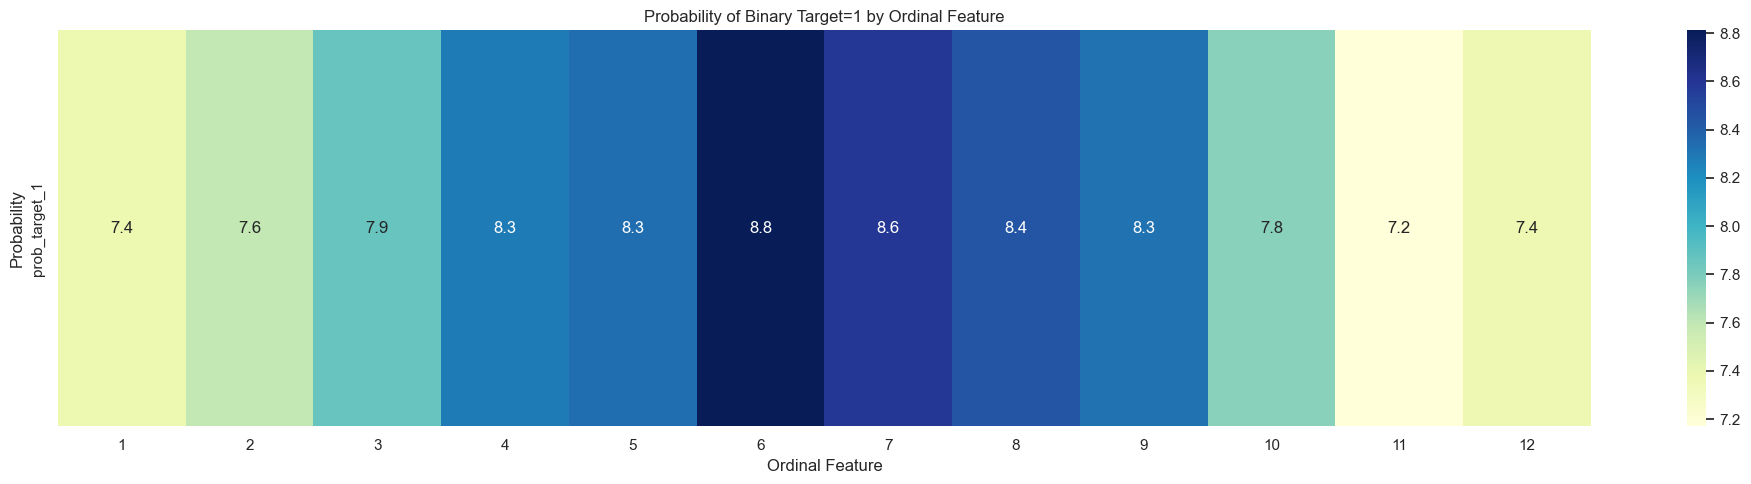

In [384]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="month")

W = -0.008, p = 0.777
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & year


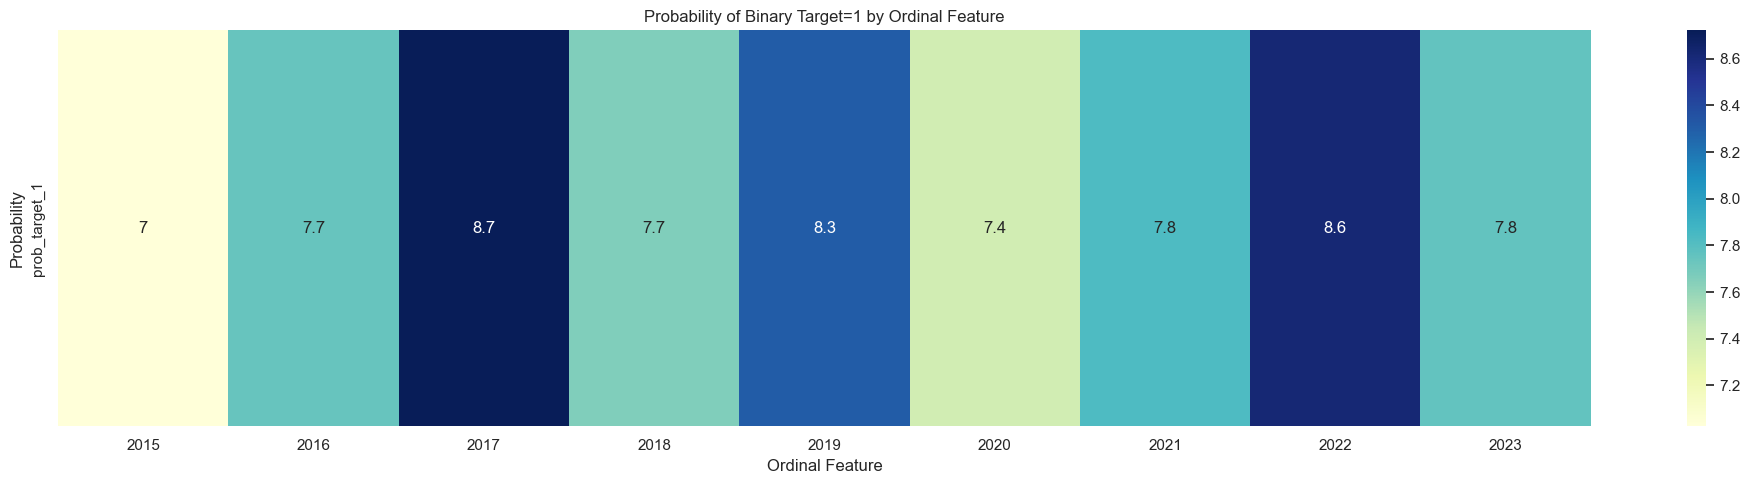

In [386]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="year");

In [387]:
def kruskal_func(Dataset:pd.DataFrame,Numericaltarget:str,CategoricalFeature:str):
    from scipy.stats import kruskal
    groups = [Dataset[Dataset[CategoricalFeature] == level][Numericaltarget] for level in Dataset[CategoricalFeature].unique()]

    stat, p = kruskal(*groups)
    if p < 0.05: 
        print(f"Kruskal-Wallis Test: Statistic={stat}, P-value={p} ==>\n The p value less than 0.05 ==> At least one group has Significant difference")
    else:
        print(f"Kruskal-Wallis Test: Statistic={stat}, P-value={p} ==>\n the p value more than 0.05 ==> No Significant difference between groups")

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    sns.boxplot(x=CategoricalFeature, y=Numericaltarget, data=Dataset, palette="Set2",ax=axes[0])
    sns.stripplot(x=CategoricalFeature, y=Numericaltarget, data=Dataset, color="black", alpha=0.6, jitter=True,ax=axes[1])
    plt.title(f"Kruskal–Wallis Test\nH={stat:.2f}, p={p:.4f}")
    plt.show()

    if p < 0.05:
        print("As At least one group has Significant difference --> posthoc_dunn test")
        import scikit_posthocs as sp
        posthoc = sp.posthoc_dunn(df_copy2, val_col='price', group_col='p_color', p_adjust='bonferroni')
        print(posthoc)
        plt.figure(figsize=(20,5))
        sns.heatmap(posthoc,annot=True,cmap="Reds", cbar=False, linewidths=0.5, linecolor='gray',fmt=".2f");

Kruskal-Wallis Test: Statistic=403.2829742894938, P-value=2.6804938199633663e-88 ==>
 The p value less than 0.05 ==> At least one group has Significant difference


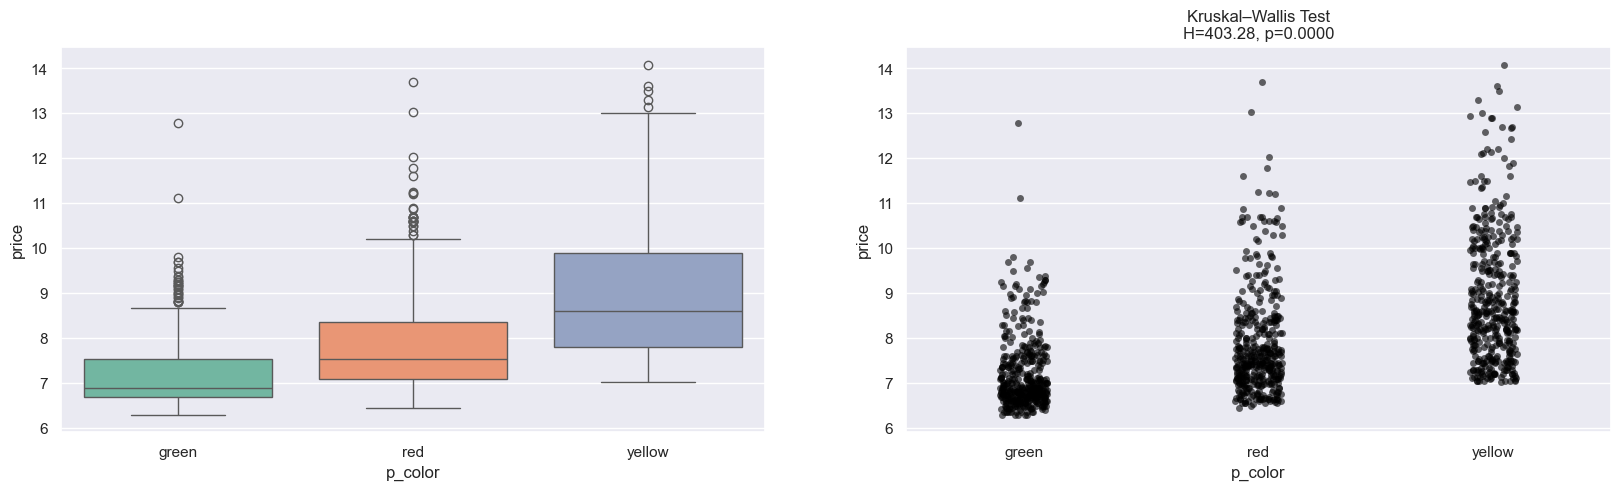

As At least one group has Significant difference --> posthoc_dunn test
               green           red        yellow
green   1.000000e+00  1.455148e-20  4.128064e-89
red     1.455148e-20  1.000000e+00  4.868764e-26
yellow  4.128064e-89  4.868764e-26  1.000000e+00


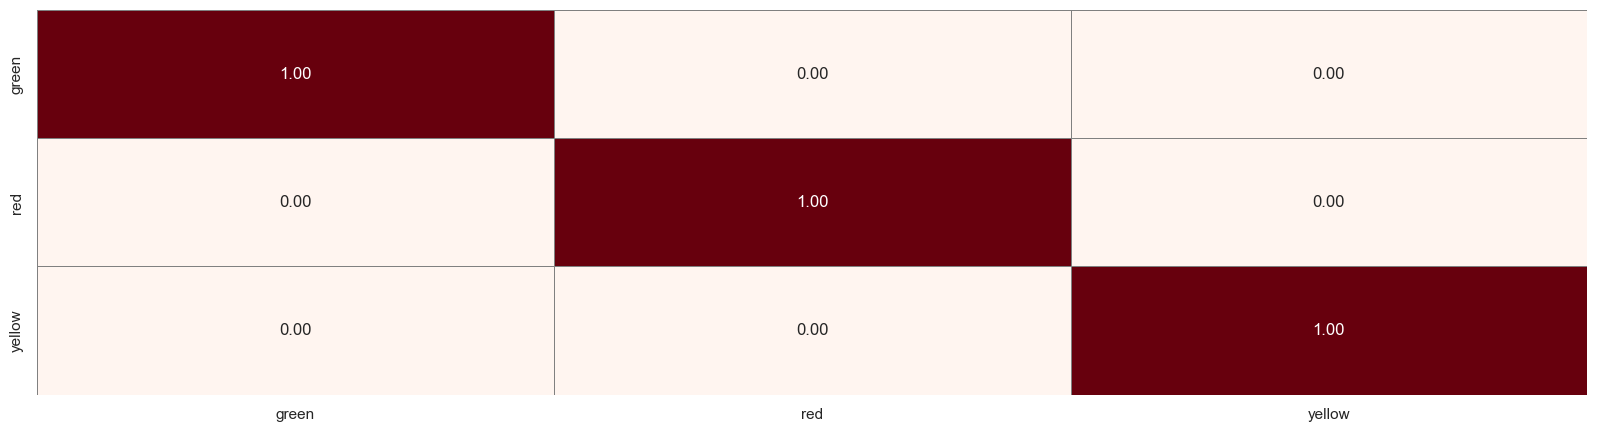

In [388]:
kruskal_func(Dataset=df_copy2,Numericaltarget="price",CategoricalFeature="p_color")